In [1]:

import argparse
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import wandb

%matplotlib inline

# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------
ENTITY  = "behzadshomali"
PROJECT = "loop_MTP_paper"


# Plot the table (experimental)

### LastOnly Tuned
|----|k=3|k=5|k=7|k=9|k=11|
|----|-----|------|----|------|---------------|
BPB | zx3sopnl | updmc9ao | e4v8vd5e | dv0u4dox
ACC|w70wwb0f|qhyhr42g|mnsa3ryd|vwm8gawa

### Uniform Tuned
|----|k=3|k=5|k=7|k=9|k=11
|----|-----|------|----|------|---------------|
BPB | i2w01mew | 4mm95tkh | mss30dzu | 2qvk0f8d
ACC | jox9mu5i | ja05pzmb | eykud9ql | x1f4rljd

### LastOnly (Learnable) Tuned
|----|k=3|k=5|k=7|k=9|k=11|
|----|-----|------|----|------|---------------|
BPB | tltnmxad | n9plnthn | pqmow3l9 | jivwk6ea | 9iqx8hk5
ACC | 1sc2cn6y | 4g29evyc | keu2xn40 | lic3xixu | None

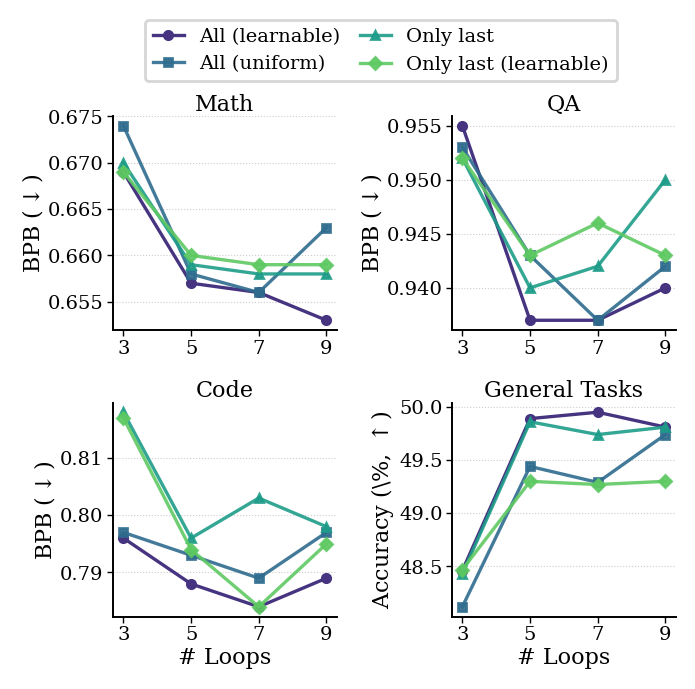

In [2]:
# ── Full gate-ablation table → 2x2 grid (one subplot per benchmark) ─────────
# Values transcribed from loop_MTP_paper/data/gate_ablate_table.tex
# Per-k columns are ordered: LoopMTP, Uni, Last, Last*

# ── ACL/EMNLP-friendly style (matches the other figures in this paper) ──────
plt.rcParams.update({
    "font.family":           "serif",
    "font.serif":            ["Times New Roman", "DejaVu Serif"],
    "mathtext.fontset":      "dejavuserif",
    "font.size":             8,
    "axes.titlesize":        8,
    "axes.labelsize":        8,
    "legend.fontsize":       7,
    "legend.title_fontsize": 7,
    "xtick.labelsize":       7,
    "ytick.labelsize":       7,
    "axes.linewidth":        0.7,
    "xtick.major.width":     0.5,
    "ytick.major.width":     0.5,
    "lines.linewidth":       1.2,
    "figure.dpi":            200,
    "savefig.dpi":           300,
    "savefig.bbox":          "tight",
})

loops = [3, 5, 7, 9, 11]
MAX_INDEX_TO_SHOW = 3

# benchmark -> gate type -> [k=3, k=5, k=7, k=9, k=11]
TABLE = {
    "Math": {
        "All (learnable)": [0.669, 0.657, 0.656, 0.653, 0.67],
        "Only last": [0.670, 0.659, 0.658, 0.658, None],
        "All (uniform)": [0.674, 0.658, 0.656, 0.663, None],
        "Only last (learnable)": [0.669, 0.660, 0.659, 0.659, 0.664],
        "Non-looped": [0.714, None, None, None, None],
    },
    "QA": {
        "All (learnable)": [0.955, 0.937, 0.937, 0.94, 0.943],
        "Only last": [0.952, 0.940, 0.942, 0.950, None],
        "All (uniform)": [0.953, 0.943, 0.937, 0.942, None],
        "Only last (learnable)": [0.952, 0.943, 0.946, 0.943, 0.946],
        "Non-looped": [1.001, None, None, None, None],
    },
    "Code": {
        "All (learnable)": [0.796, 0.788, 0.784, 0.789, 0.803],
        "Only last": [0.818, 0.796, 0.803, 0.798, None],
        "All (uniform)": [0.797, 0.793, 0.789, 0.797, None],
        "Only last (learnable)": [0.817, 0.794, 0.784, 0.795, 0.818],
        "Non-looped": [0.868, None, None, None, None],
    },
    "General Tasks": {
        "All (learnable)": [48.46, 49.89, 49.95, 49.81, 49.74],
        "Only last": [48.43, 49.86, 49.74, 49.81, None],
        "All (uniform)": [48.12, 49.44, 49.29, 49.74, None],
        "Only last (learnable)": [48.47, 49.30, 49.27, 49.30, None],
    },
}

GATES = [
    "All (learnable)",
    "All (uniform)",
    "Only last",
    "Only last (learnable)",
    # "Non-looped",
]
BENCHMARKS = list(TABLE.keys())

# Benchmarks reported as BPB (lower is better) vs. accuracy-style (higher is better)
BPB_BENCHMARKS = {"Math", "QA", "Code", "Average (BPB)"}

PALETTE    = [plt.cm.viridis(v) for v in np.linspace(0.15, 0.75, len(GATES))]
# LINESTYLES = ["-", "--", "-.", ":"]
LINESTYLES = ["-"] * 10
ALPHAS = [0.9] * 10
ALPHAS[0] = 1.0
MARKERS    = ["o", "s", "^", "D"]
NONLOOPED_COLOR = "#444444"

fig, axes = plt.subplots(2, 2, figsize=(3.3, 2.9))
axes_flat = axes.flatten()

for cnt, (ax, bench) in enumerate(zip(axes_flat, BENCHMARKS)):
    for j, gate in enumerate(GATES):
        if "non-looped" in gate.lower():
            continue
        ys = np.array([np.nan if v is None else v for v in TABLE[bench][gate]], dtype=float)[:MAX_INDEX_TO_SHOW+1]
        xs = np.array(loops, dtype=float)[:MAX_INDEX_TO_SHOW+1]
        mask = ~np.isnan(ys)
        if not mask.any():
            continue
        ax.plot(
            xs[mask], ys[mask],
            label=gate,
            color=PALETTE[j],
            linestyle=LINESTYLES[j],
            alpha=ALPHAS[j],
            marker=MARKERS[j],
            markersize=3,
            linewidth=1.2,
        )

    ## Non-looped baseline as a horizontal reference line
    # nl_vals = [v for v in TABLE[bench]["Non-looped"] if v is not None]
    # if nl_vals:
    #     ax.axhline(
    #         nl_vals[0],
    #         color=NONLOOPED_COLOR,
    #         linestyle=":",
    #         linewidth=1.4,
    #         label="Non-looped",
    #     )

    ax.set_title(bench, pad=2)
    if cnt > 1:
        ax.set_xlabel("# Loops", labelpad=1)
    ax.set_ylabel("BPB ($\\downarrow$)" if bench in BPB_BENCHMARKS else "Accuracy (\\%, $\\uparrow$)", labelpad=1)
    ax.set_xticks(loops[:MAX_INDEX_TO_SHOW+1])
    
    ax.tick_params(length=2, pad=1.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.yaxis.grid(True, linestyle=":", linewidth=0.4, alpha=0.6, color="#aaaaaa")
    ax.set_axisbelow(True)

handles, labels = axes_flat[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="upper center",
    bbox_to_anchor=(0.55, 1.14),
    ncol=len(handles)//2,
    columnspacing=1.0,
    handlelength=1.6,
    frameon=True,
    framealpha=0.8,
    edgecolor="#cccccc",
)

fig.tight_layout(pad=0.1, w_pad=1, h_pad=1)
Path("./plots").mkdir(exist_ok=True)
fig.savefig("./plots/gate_ablate_table_grid.pdf", bbox_inches="tight")
plt.show()
